# 02 — D2 `rule_composite_riskoff` (Reglas / Umbrales, voto multivariante)

Regla **compuesta** y causal: agrega 4 señales de estrés ya causales de `features.parquet` en un **score de risk-off** (ALTO = estrés) y lo umbraliza con **histéresis** (τ_in/τ_out) + **dwell-time** mínimo, igual que D1 pero sobre un VOTO multivariante en vez de un único nivel de VIX. 2 estados: 0=calma, 1=crisis (varias señales risk-off simultáneas).

**Por qué un voto y no solo el VIX.** D1 dejó un hueco diagnóstico: el bear market de tipos de **2022** fue un deterioro lento, sin pico de miedo equity, y un detector univariante de VIX lo infra-detecta. La hipótesis de D2 es que una crisis sistémica raramente se manifiesta en un único termómetro: suele combinar repunte de volatilidad (VIX), deterioro del crédito (high-yield cae frente a treasuries), aplanamiento/inversión de la curva y drawdown del equity. Sumar esas cuatro voces debería **rellenar** lo que el miedo solo no ve —al precio de un nuevo problema, la **calibración de los pesos** del voto—.

**Señales y orientación** (signo con que entran al score, ALTO=estrés):
- `VIX_level_z` (+): miedo equity (bloom2009).
- `credit_spread_z` (−): ret(HYG)−ret(IEF); el deterioro de crédito lo vuelve NEGATIVO (Gilchrist-Zakrajšek 2012).
- `yield_slope_z` (−): pendiente 10Y−3M; curva baja/invertida = estrés (Estrella-Mishkin 1998). Signo INVERTIDO.
- `SP500_drawdown` (−): drawdown corriente ∈[−1,0] (kritzman2012).

**Ventana**: crédito (HYG) y curva existen en `features.parquet` desde 2007-07. Con `train_size≈8 años` el primer bloque OOS cae hacia 2015, así que **2008 y 2011 quedan en el train inicial → cobertura NaN out-of-sample** (correcto y declarado): D2 solo se evalúa OOS sobre 2020 y 2022.

**Hipótesis CHECKPOINT 2 (D2)**: *captará estrés multivariante equity+crédito+curva en 2008/2011/2020/2022; fallará por calibración de pesos sensible*. Verificamos al final.

### Índice

Hoja de ruta del notebook —del voto crudo al veredicto sobre la calibración de pesos— para navegar las secciones sin perder el hilo argumental:

1. **Las 4 señales del voto** + retorno del S&P 500 (`market_returns`).
2. **Dirección de estrés empírica** de cada señal por ventana (la grieta de la curva).
3. **El detector D2 y su score compuesto** causal (μ/σ del train, τ_in/τ_out).
4. **Walk-forward causal** (2008/2011 en el train inicial → NaN OOS).
5. **Evaluación estandarizada** y fila de métricas (CSV `metrics_02_*`, ~32 col).
6. **S&P 500 coloreado por régimen** — primera lectura visual *(d2_regime_sp500)*.
7. **Score vs umbral + contribución + timeline** — el detector por dentro *(d2_score_timeline)*.
8. **Distribución del score compuesto por régimen** — la separación calma vs crisis, de un vistazo *(d2_score_dist_by_regime)*.
9. **Descomposición de la contribución por señal** — heatmap señal×tiempo + qué señal domina en 2020 vs 2022 *(d2_signal_decomposition)*.
10. **Espacio de las 4 señales** (PCA) coloreado por régimen — separabilidad *(d2_signal_space)*.
11. **Verificación explícita** contra crisis y trampas (cobertura/falsas alarmas).
12. **Comparativa visual D1 vs D2** — ¿aporta el voto sobre el VIX-solo? *(d2_vs_d1)* + **veredicto** sobre la hipótesis del CP2.

Las figuras se guardan en `results/` con prefijo `d2_` y se embeben en el informe LaTeX de la Capa 1.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev, viz
from detectors.rule_composite_riskoff import RuleCompositeRiskoff

viz.use_house_style()   # paleta y estilo homogéneos con el resto del banco
feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('features:', feats.shape, '|', feats.index.min().date(), '->', feats.index.max().date())

features: (4665, 15) | 2007-07-06 -> 2026-06-12


## 1. Señales del voto + retorno del S&P 500 (market_returns)

`X` = las 4 señales causales del score. `market_returns` = **retorno log del S&P 500** (`np.log(raw['SP500']/raw['SP500'].shift(1))`) reindexado a `X`. Lo pasaremos SIEMPRE a `walk_forward` y a `evaluate` para que el núcleo re-fije el orden económico (0=calma..n−1=crisis) y NO haya warning de fallback.

In [2]:
SIGNALS = ['VIX_level_z', 'credit_spread_z', 'yield_slope_z', 'SP500_drawdown']
X = feats[SIGNALS].dropna().copy()
X.index = pd.to_datetime(X.index); X = X.sort_index()
market_returns = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
market_returns = market_returns.reindex(X.index)
print('X (desde HYG/curva):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('Orientación estrés (ALTO=risk-off):', RuleCompositeRiskoff().signs)
X.head(3)

X (desde HYG/curva): (4665, 4) | 2007-07-06 -> 2026-06-12
Orientación estrés (ALTO=risk-off): {'VIX_level_z': 1, 'credit_spread_z': -1, 'yield_slope_z': -1, 'SP500_drawdown': -1}


,VIX_level_z,credit_spread_z,yield_slope_z,SP500_drawdown
date,,,,
2007-07-06,-0.649340,1.076833,-1.177578,-0.005678
2007-07-09,-0.580730,-0.205217,-1.203925,-0.004762
2007-07-10,-0.205364,-2.833249,-1.324621,-0.018880


## 2. Dirección de estrés empírica de cada señal (la grieta de la curva)

**Dirección de estrés empírica** de cada señal: media por ventana. Confirma los signos (VIX alto, credit_spread_z bajo/negativo, yield_slope_z bajo, drawdown negativo = estrés). El detalle clave para entender D2 está en la fila de la **curva**: en 2008/2011 se EMPINÓ (Fed recortando el corto), de modo que es una señal de aviso **adelantado** (predice recesión) y no contemporáneo. En 2020 domina el bloque equity (VIX + drawdown); en 2022, en cambio, la curva se **invirtió** y el crédito se deterioró mientras el VIX se quedó moderado. Esa asimetría —qué voz suena en cada episodio— es exactamente la **grieta** por la que entra (o se escapa) el voto compuesto, y la raíz del problema de calibración de pesos que discutiremos al final.

In [3]:
wins = {**ev.CRISIS_WINDOWS, 'calm_2017': ('2017-01-01','2017-12-31')}
tbl = {w: {c: round(float(feats.loc[a:b, c].mean()), 2) for c in SIGNALS}
       for w, (a, b) in wins.items()}
pd.DataFrame(tbl).T

,VIX_level_z,credit_spread_z,yield_slope_z,SP500_drawdown
GFC_2008,3.92,-0.21,0.82,-0.42
EuroDebt_2011,1.30,-0.09,0.35,-0.22
COVID_2020,3.46,-0.34,-1.22,-0.18
Inflation_2022,0.83,0.03,-0.50,-0.14
calm_2017,-1.08,0.01,-0.48,-0.01


## 3. El detector D2 y su score compuesto causal

`RuleCompositeRiskoff(q_in=0.90, q_out=0.70, min_dwell=5)`: cada señal se orienta (signo·valor), se re-estandariza con μ/σ **del train** (causal) y se promedia → **score de risk-off**. τ_in/τ_out = percentiles 90/70 del score en el train. Ajuste sobre todo el histórico SOLO para inspección (la evaluación honesta es el walk-forward de la sección 4).

**El problema de calibración**, en una frase: con `weights=None` las cuatro señales pesan IGUAL. Pero la re-estandarización causal (μ/σ del train) garantiza que sean comparables en escala, NO que aporten lo mismo en cada crisis. Un voto de pesos iguales es deliberadamente agnóstico —no privilegia el VIX como D1—, a cambio de diluir la señal cuando solo una o dos voces se activan (p. ej. la curva adelantada). Mantenemos pesos iguales como baseline honesto y dejamos la sensibilidad de la ponderación como discusión, no como sobreajuste.

In [4]:
det0 = RuleCompositeRiskoff(q_in=0.90, q_out=0.70, min_dwell=5).fit(X)
print(f'τ_in  (q=0.90) = {det0._tau_in:.3f}  (unidades de score)')
print(f'τ_out (q=0.70) = {det0._tau_out:.3f}')
print('pesos:', det0.weights)
print('bibliografía:', det0.bibliography)
# Re-fijar orden económico con market_returns (lo que hace walk_forward por fold).
det0.label_states_economically(X, market_returns=market_returns)
print('canonical order =', det0._canonical_order, '| crisis_state =', det0.crisis_state)
states_is = pd.Series(det0.predict(X), index=X.index)
byst = {int(s): round(float(market_returns[states_is == s].mean()), 5) for s in [0, 1]}
print('retorno medio S&P por estado:', byst, '-> 1=crisis (peor) =', byst[1] < byst[0])
assert det0.crisis_state == 1 and byst[1] < byst[0], 'crisis canónico != voto risk-off'
print('% días crisis in-sample:', round(float((states_is == det0.crisis_state).mean()), 3))

τ_in  (q=0.90) = 0.616  (unidades de score)
τ_out (q=0.70) = 0.140
pesos: {'VIX_level_z': 1.0, 'credit_spread_z': 1.0, 'yield_slope_z': 1.0, 'SP500_drawdown': 1.0}
bibliografía: ['reglas_gilchristzakrajsek2012', 'estrellamishkin1998', 'reglas_bloom2009', 'kritzman2012']
canonical order = [0 1] | crisis_state = 1
retorno medio S&P por estado: {0: 0.00116, 1: -0.00337} -> 1=crisis (peor) = True
% días crisis in-sample: 0.192


## 4. Walk-forward causal (2008/2011 en el train inicial → NaN OOS)

`ev.walk_forward` reentrena el detector en ventanas crecientes y predice el siguiente bloque sin ver el futuro, **pasando `market_returns`** para re-fijar el orden de estados por fold. Como `X` arranca en 2007 y `train_size≈8 años`, el panel OOS empieza hacia 2015: **2008 y 2011 NO son evaluables OOS** (caen en el train), solo 2020 y 2022.

In [5]:
factory = lambda: RuleCompositeRiskoff(q_in=0.90, q_out=0.70, min_dwell=5)
panel = ev.walk_forward(factory, X, market_returns=market_returns,
                        train_size=252*8, step=21, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

Panel OOS: (2649, 3) | 2015-09-15 -> 2026-06-12


,state,p_crisis,fold
date,,,
2015-09-15,0,0.0,0
2015-09-16,0,0.0,0
2015-09-17,0,0.0,0


## 5. Evaluación estandarizada y fila de métricas (32 columnas)

`ev.evaluate` con `market_returns` calcula cobertura por crisis, falsas alarmas (global y en trampas), lead/lag, switching/persistencia y estabilidad. Se vuelca a `results/metrics_02_rule_composite_riskoff.csv`.

In [6]:
res = ev.evaluate(det0, panel, market_returns=market_returns, X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_02_rule_composite_riskoff.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('retorno medio S&P por estado:', {k: round(v,5) for k,v in res.extra['mean_return_by_state'].items()})
print('columnas:', row.shape[1], '| guardado:', out_csv.name)
row.T

ventana_eval: 2015-09-15→2026-06-12 (n=2649)
retorno medio S&P por estado: {0: 0.00117, 1: -0.00222}
columnas: 32 | guardado: metrics_02_rule_composite_riskoff.csv


,0
detector,rule_composite_riskoff
n_states,2
ventana_eval,2015-09-15→2026-06-12 (n=2649)
oos_start,2015-09-15
oos_end,2026-06-12
n_oos,2649
false_alarm_rate,0.724508
switching_rate,0.038505
mean_regime_duration,25.718447
label_stability,0.999622


## 6. Visualización — S&P 500 coloreado por régimen (OOS)

S&P 500 (log) con los días OOS clasificados como **crisis** sombreados; bandas de crisis conocidas (rojo) y trampas 2013/2018 (naranja). La zona pre-2015 es el train inicial (sin etiqueta OOS).

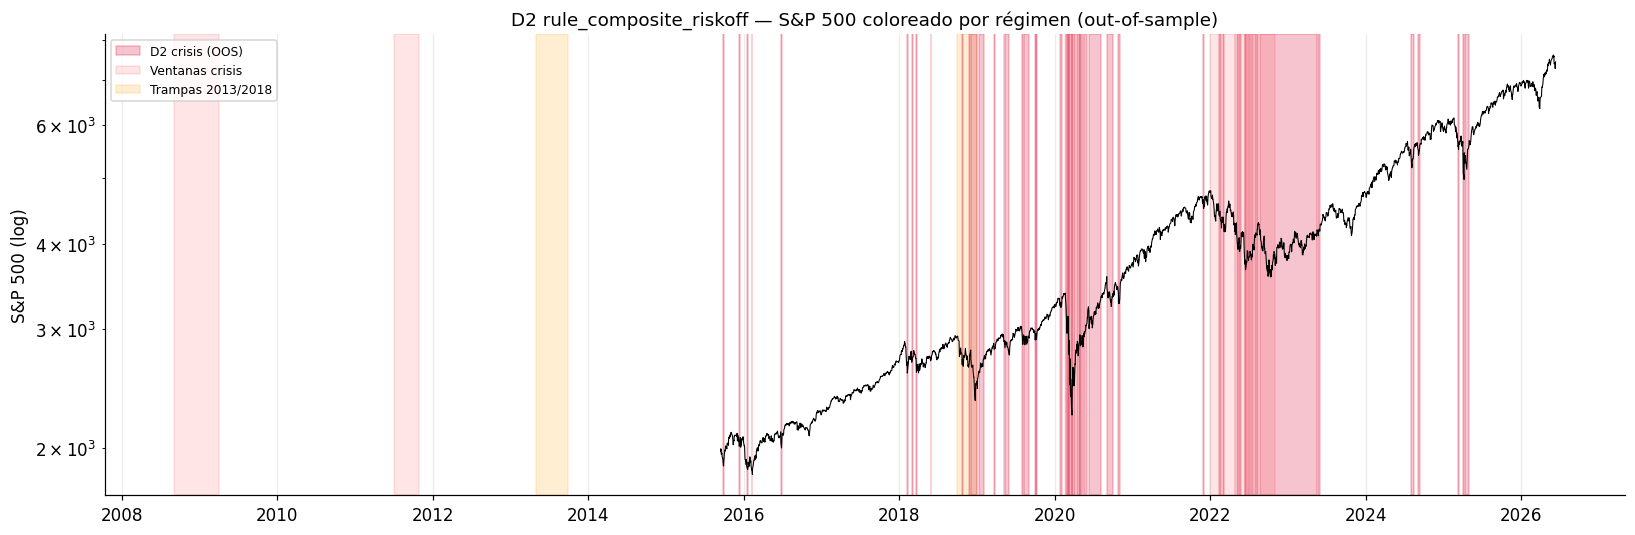

In [7]:
spx = raw['SP500'].reindex(panel.index)
is_crisis = (panel['state'] == det0.crisis_state)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.index, spx, color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
ymin, ymax = ax.get_ylim()
ax.fill_between(panel.index, ymin, ymax, where=is_crisis.values, color='crimson',
                alpha=0.25, step='mid', zorder=1)
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18, zorder=0)
handles = [Patch(color='crimson', alpha=0.25, label='D2 crisis (OOS)'),
           Patch(color='red', alpha=0.10, label='Ventanas crisis'),
           Patch(color='orange', alpha=0.18, label='Trampas 2013/2018')]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_title('D2 rule_composite_riskoff — S&P 500 coloreado por régimen (out-of-sample)')
fig.tight_layout(); fig.savefig(RESULTS / 'd2_regime_sp500.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Score compuesto vs umbral + contribución de cada señal + timeline

Arriba: score de risk-off OOS con τ_in/τ_out (histéresis). Medio: z orientada de cada señal (ALTO=estrés) para ver QUÉ aporta el voto en cada episodio. Abajo: timeline de régimen (banda roja = crisis). Esta es la vista panorámica; las secciones 8 y 9 destilan estas mismas series en dos figuras dedicadas (la separación calma/crisis del score y la descomposición por señal).

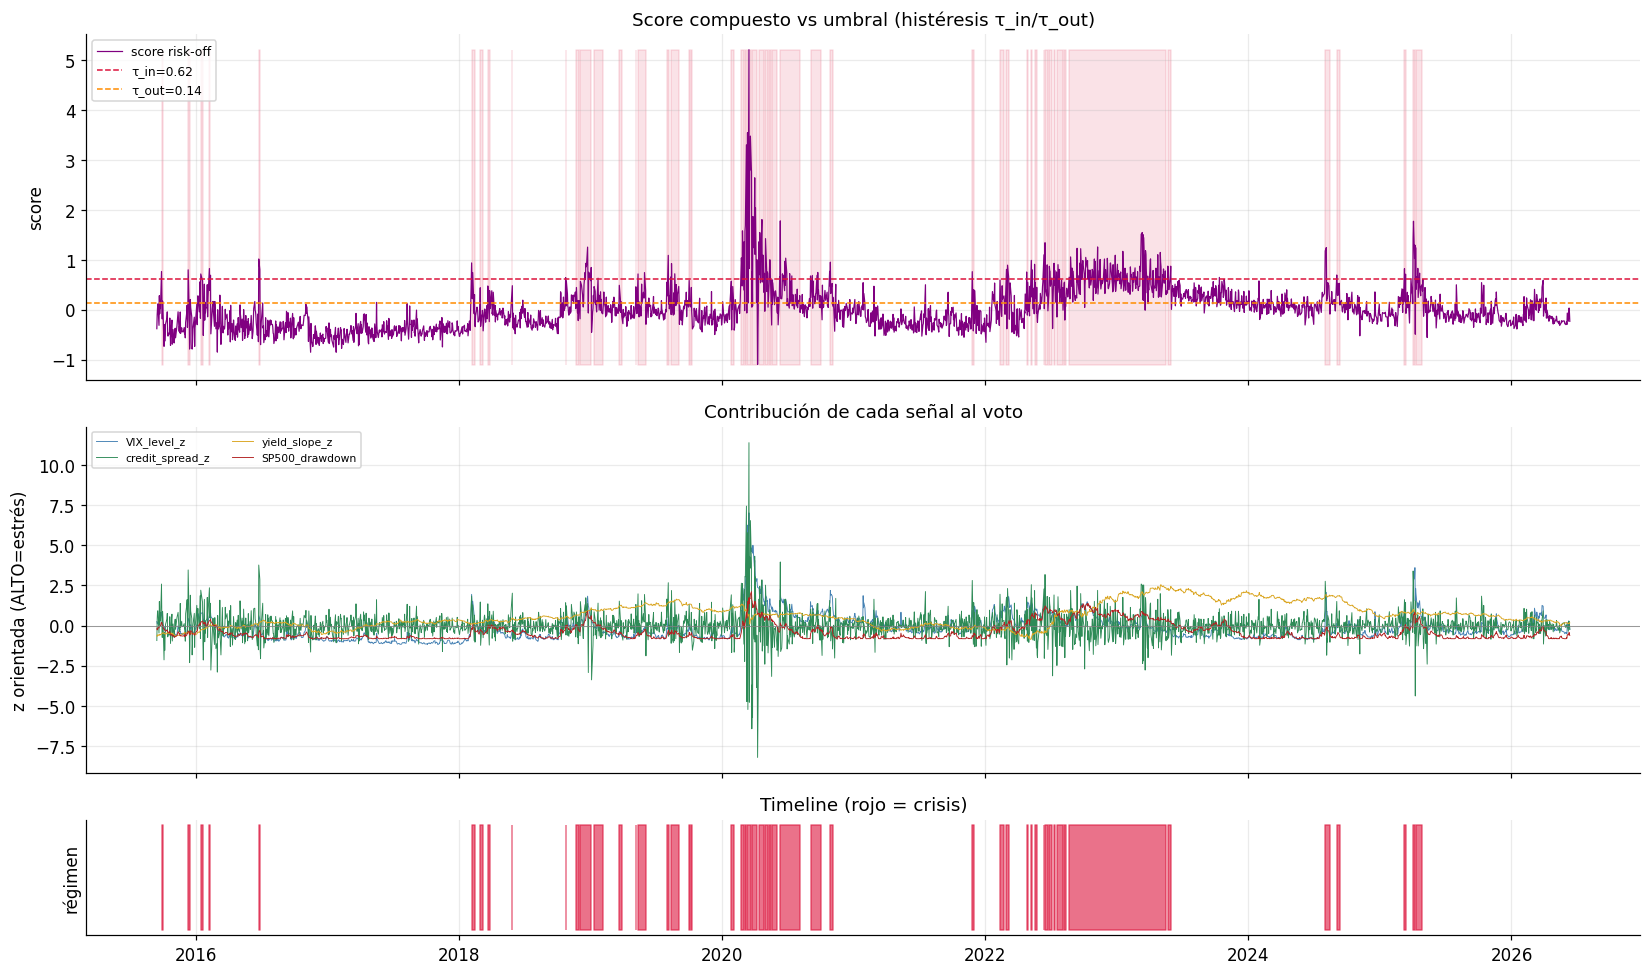

In [8]:
score = pd.Series(det0.composite_score(X), index=X.index).reindex(panel.index)
# z orientadas por señal (con μ/σ del fit de inspección)
ori = det0._oriented(X.reindex(panel.index))
zsig = {f: (ori[f] - det0._mu[f]) / (det0._sigma[f] if det0._sigma[f] > 0 else 1.0)
        for f in det0.features}
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 3, 1]})
ax1.plot(score.index, score, color='purple', lw=0.8, label='score risk-off')
ax1.axhline(det0._tau_in, color='crimson', ls='--', lw=1, label=f'τ_in={det0._tau_in:.2f}')
ax1.axhline(det0._tau_out, color='darkorange', ls='--', lw=1, label=f'τ_out={det0._tau_out:.2f}')
ax1.fill_between(panel.index, score.min(), score.max(), where=is_crisis.values,
                 color='crimson', alpha=0.12, step='mid')
ax1.set_ylabel('score'); ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('Score compuesto vs umbral (histéresis τ_in/τ_out)')
for f, c in zip(det0.features, ['steelblue','seagreen','goldenrod','firebrick']):
    ax2.plot(panel.index, zsig[f], lw=0.6, color=c, label=f)
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_ylabel('z orientada (ALTO=estrés)'); ax2.legend(loc='upper left', fontsize=7, ncol=2)
ax2.set_title('Contribución de cada señal al voto')
ax3.fill_between(panel.index, 0, 1, where=is_crisis.values, color='crimson', alpha=0.6, step='mid')
ax3.set_yticks([]); ax3.set_ylabel('régimen'); ax3.set_title('Timeline (rojo = crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd2_score_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Distribución del score compuesto por régimen (la separación, de un vistazo)

Igual que en D1 mirábamos la distribución del nivel de VIX por estado, aquí miramos la del **score compuesto**. Si el voto multivariante tiene poder discriminante, su densidad condicionada al régimen debería estar **claramente desplazada**: masa baja y compacta en calma, cola alta y dispersa en crisis. Es la evidencia más directa de que la agregación de las cuatro señales —y no solo el miedo— produce un cribado limpio.

El violín separa el `score risk-off` en los dos estados OOS y superpone τ_in y τ_out: la **banda muerta** de la histéresis (franja dorada) cae justo en la **zona de solape** entre las dos distribuciones, que es exactamente donde un umbral simple parpadearía. Un solape estrecho confirma que el voto separa bien; un solape ancho avisaría de que los pesos iguales diluyen la señal en los episodios donde solo una o dos voces se activan (preludio de la discusión de calibración).

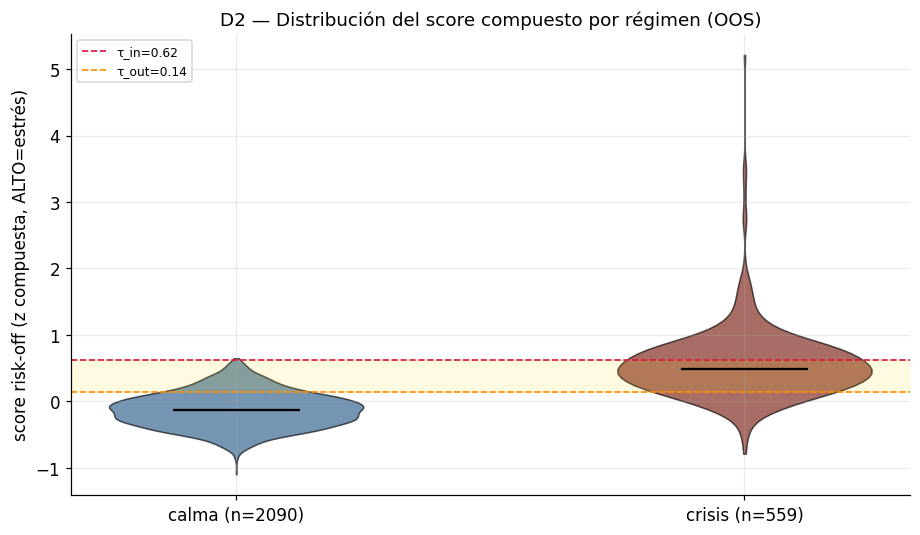

mediana score  calma=-0.13  crisis=0.49  (salto=0.63)


In [9]:
score_oos = pd.Series(det0.composite_score(X), index=X.index).reindex(panel.index)
states_oos = panel['state'].astype('Int64')
m = score_oos.notna() & states_oos.notna()
states_m = states_oos[m].astype(int)
fig, ax = plt.subplots(figsize=(8.5, 5))
viz.plot_distribution_by_regime(
    score_oos[m], states_m, crisis_state=det0.crisis_state,
    labels={0: 'calma', 1: 'crisis'}, kind='violin', ax=ax,
    xlabel='score risk-off (z compuesta, ALTO=estrés)',
    title='D2 — Distribución del score compuesto por régimen (OOS)')
ax.axhline(det0._tau_in, color='crimson', ls='--', lw=1.1, label=f'τ_in={det0._tau_in:.2f}')
ax.axhline(det0._tau_out, color='darkorange', ls='--', lw=1.1, label=f'τ_out={det0._tau_out:.2f}')
ax.axhspan(det0._tau_out, det0._tau_in, color='gold', alpha=0.12)
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / 'd2_score_dist_by_regime.png', dpi=110, bbox_inches='tight')
plt.show()
med_c = float(np.nanmedian(score_oos[m].values[states_m.values == 0]))
med_k = float(np.nanmedian(score_oos[m].values[states_m.values == det0.crisis_state]))
print(f'mediana score  calma={med_c:.2f}  crisis={med_k:.2f}  (salto={med_k - med_c:.2f})')

## 9. Descomposición de la contribución de cada señal (¿quién manda en cada crisis?)

La sección 7 superpone las cuatro z en un mismo panel; aquí las **separamos** para responder a la pregunta de fondo: *¿qué señal domina cada episodio?* La figura tiene dos partes complementarias:

- **Arriba — heatmap señal × tiempo** de la z orientada (rojo = estrés, azul = calma) a lo largo de todo el OOS. Permite leer la dinámica de cada voz por separado y ver dónde se enciende la **grieta de la curva**: en 2022 `yield_slope_z` vira a rojo (curva invertida) mientras el VIX se queda tibio.
- **Abajo — barras de la contribución media** de cada señal en **2020 vs 2022**. Aquí se ve el contraste de regímenes de un golpe: **2020** es un shock de equity (VIX + drawdown dominan, la curva apenas aporta porque se empinó), mientras **2022** es un estrés de crédito/tipos (la curva y el spread llevan la voz cantante). Es la justificación visual de por qué el voto compuesto puede captar 2022 donde D1 (VIX-solo) se queda corto —y, a la vez, por qué unos pesos iguales son un compromiso y no un óptimo—.

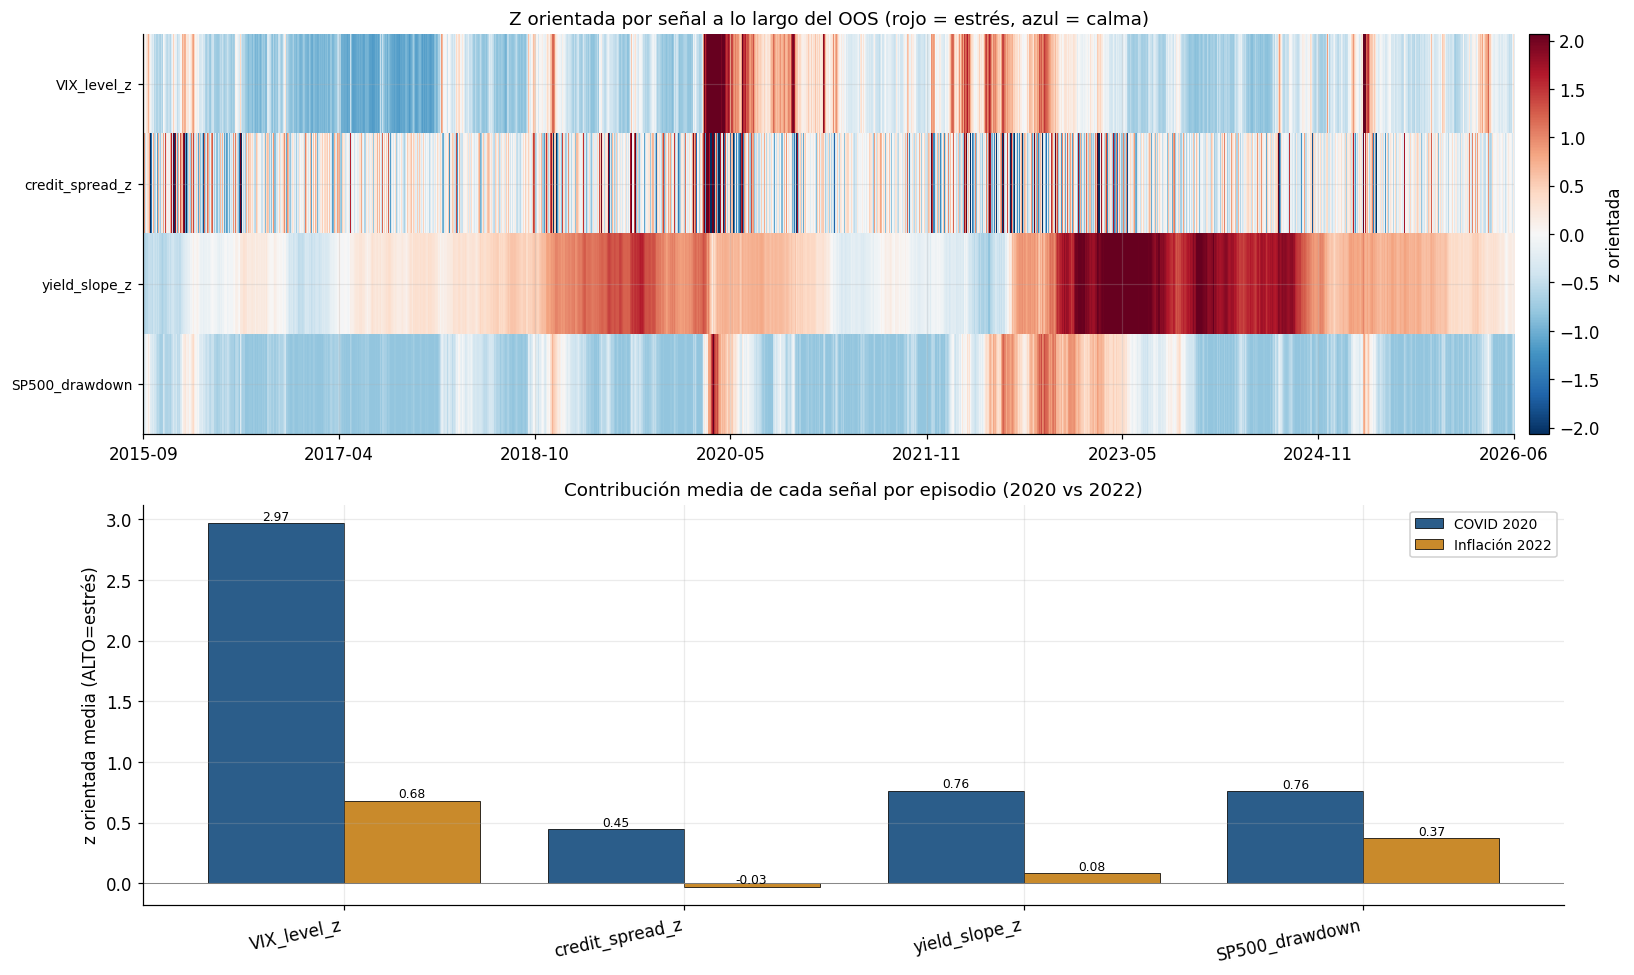

COVID 2020      : señal dominante = VIX_level_z  (z media=2.97)
Inflación 2022  : señal dominante = VIX_level_z  (z media=0.68)


In [10]:
ori = det0._oriented(X.reindex(panel.index))
zsig = {f: (ori[f] - det0._mu[f]) / (det0._sigma[f] if det0._sigma[f] > 0 else 1.0)
        for f in det0.features}
zmat = pd.DataFrame(zsig, index=panel.index)[det0.features]
fig, (axh, axb) = plt.subplots(2, 1, figsize=(15, 9),
                               gridspec_kw={'height_ratios': [2, 2]})
# (a) Heatmap señal x tiempo de la z orientada (ALTO=estrés).
M = zmat.T.values
vmax = float(np.nanpercentile(np.abs(M), 98)) or 1.0
im = axh.imshow(M, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                interpolation='nearest')
axh.set_yticks(range(len(det0.features))); axh.set_yticklabels(det0.features, fontsize=9)
ticks = np.linspace(0, len(zmat) - 1, 8).astype(int)
axh.set_xticks(ticks)
axh.set_xticklabels([str(zmat.index[t])[:7] for t in ticks], rotation=0)
axh.set_title('Z orientada por señal a lo largo del OOS (rojo = estrés, azul = calma)')
fig.colorbar(im, ax=axh, fraction=0.025, pad=0.01, label='z orientada')
# (b) Contribución media por señal en cada episodio (¿quién domina?).
episodes = {'COVID 2020': ev.CRISIS_WINDOWS['COVID_2020'],
            'Inflación 2022': ev.CRISIS_WINDOWS['Inflation_2022']}
ep_means = {ep: zmat.loc[a:b].mean() for ep, (a, b) in episodes.items()}
viz.plot_grouped_bars(
    list(det0.features),
    {ep: [float(ep_means[ep][f]) for f in det0.features] for ep in episodes},
    ylabel='z orientada media (ALTO=estrés)', ax=axb, rotation=12, value_labels=True,
    title='Contribución media de cada señal por episodio (2020 vs 2022)')
axb.axhline(0, color='gray', lw=0.6)
fig.tight_layout(); fig.savefig(RESULTS / 'd2_signal_decomposition.png', dpi=110, bbox_inches='tight')
plt.show()
for ep in episodes:
    dom = ep_means[ep].idxmax()
    print(f'{ep:16s}: señal dominante = {dom}  (z media={ep_means[ep][dom]:.2f})')

## 10. Espacio de las 4 señales (PCA) coloreado por régimen

Una última lectura geométrica: proyectamos las 4 señales causales a 2 componentes principales y coloreamos cada día OOS por su régimen. Si el voto compuesto es coherente, los días de **crisis** deberían ocupar una región **separada** (la periferia de estrés: VIX alto, crédito y curva deteriorados, drawdown profundo) frente a la nube compacta de calma. El grado de solape entre ambas nubes es la versión multivariante del solape que veíamos en el violín de la sección 8: cuanto más limpia la separación, más defendible el voto con pesos iguales.

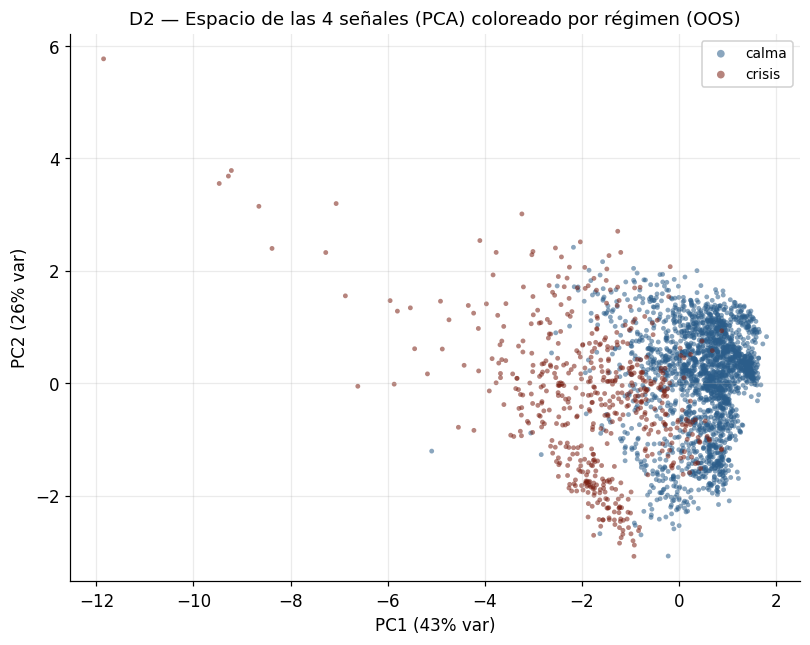

In [11]:
states_oos = panel['state'].astype('Int64')
Xoos = X.reindex(panel.index)
m = Xoos.notna().all(axis=1) & states_oos.notna()
fig, ax = plt.subplots(figsize=(7.5, 6))
viz.plot_feature_space_scatter(
    Xoos[m], states_oos[m].astype(int), use_pca=True, crisis_state=det0.crisis_state,
    labels={0: 'calma', 1: 'crisis'}, ax=ax,
    title='D2 — Espacio de las 4 señales (PCA) coloreado por régimen (OOS)')
fig.tight_layout(); fig.savefig(RESULTS / 'd2_signal_space.png', dpi=110, bbox_inches='tight')
plt.show()

## 11. Verificación explícita contra crisis y trampas

Cobertura (% días crisis) en cada ventana conocida y en cada trampa. 2008/2011 salen NaN (en el train inicial). Para 2020/2022: alto=bueno. Para trampas 2013/2018: bajo=bueno.

In [12]:
states_oos = panel['state']
cov = ev.crisis_coverage(states_oos, det0.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det0.crisis_state)
print('=== COBERTURA EN CRISIS (alto = bueno; NaN = en train inicial) ===')
for k, v in cov.items():
    tag = 'sin OOS (train)' if v != v else ('OK' if v >= 0.5 else 'BAJA')
    print(f'  {k:16s}: ' + ('  NaN' if v != v else f'{v:6.2%}') + f'  [{tag}]')
print('\n=== ACTIVACIÓN EN TRAMPAS (bajo = bueno) ===')
for k, v in fa.items():
    print(f'  {k:16s}: ' + ('  NaN (train)' if v != v else f'{v:6.2%}'))
print(f'\nfalse_alarm_rate global: {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f}  |  duración media régimen: {res.mean_regime_duration:.1f} días')
print(f'label_stability: {res.label_stability:.3f}')

=== COBERTURA EN CRISIS (alto = bueno; NaN = en train inicial) ===
  GFC_2008        :   NaN  [sin OOS (train)]
  EuroDebt_2011   :   NaN  [sin OOS (train)]
  COVID_2020      : 84.00%  [OK]
  Inflation_2022  : 53.85%  [OK]

=== ACTIVACIÓN EN TRAMPAS (bajo = bueno) ===
  TaperTantrum_2013:   NaN (train)
  Selloff_Q4_2018 : 42.37%

false_alarm_rate global: 72.45%
switching_rate: 0.0385  |  duración media régimen: 25.7 días
label_stability: 1.000


## 12. Comparación con D1 (VIX-solo) y veredicto sobre la hipótesis del CP2

La pregunta clave: ¿el voto compuesto capta estrés multivariante (crédito + drawdown + curva) que el VIX solo no ve, sobre todo en el bear market de tipos de **2022**? Cargamos la fila de D1 (`metrics_01_rule_vix_threshold.csv`) y la comparamos en tres ejes: **cobertura** (COVID 2020, Inflación 2022), **falsas alarmas** y **persistencia**. Primero la lectura visual (`d2_vs_d1.png`), luego la tabla numérica y el veredicto.

Nota metodológica: la trampa de 2018 y las crisis de 2008/2011 caen en el train inicial de D2, así que la comparación de falsas alarmas se hace sobre la tasa **global** (ambos detectores la tienen OOS), no sobre la trampa de 2018.

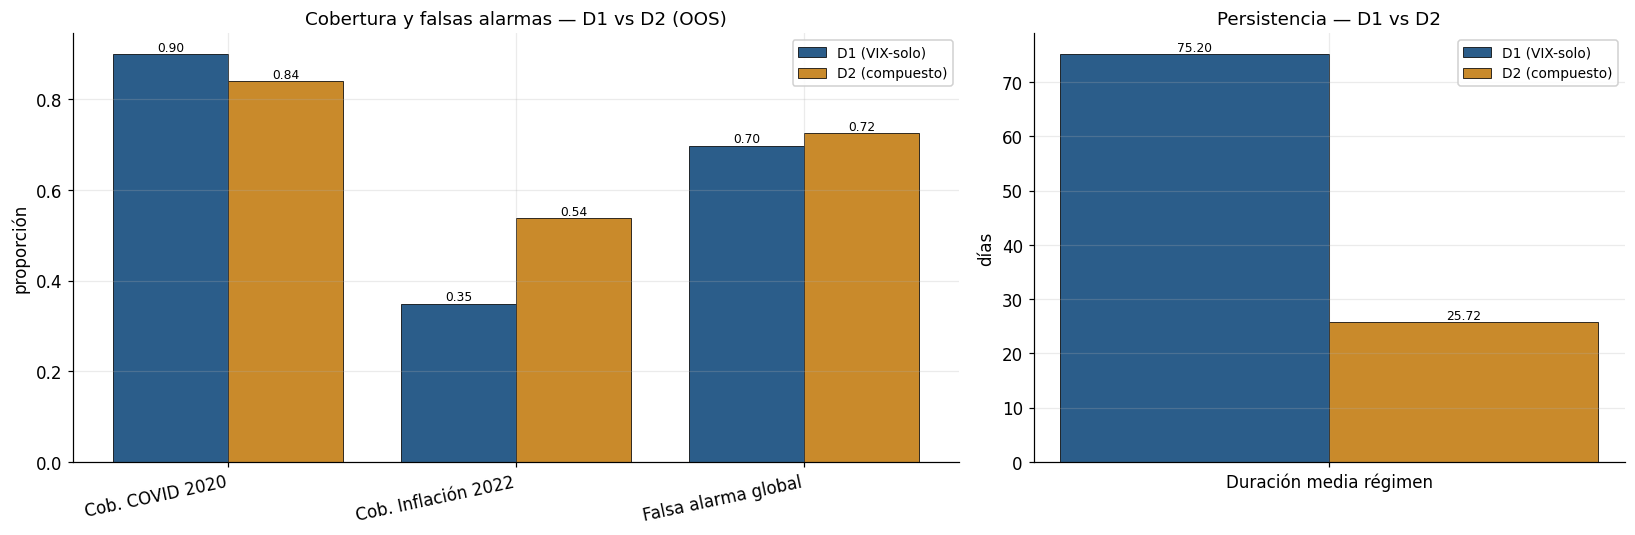

Inflación 2022: D1(VIX)=34.9%  ->  D2(compuesto)=53.8%  (Δ=+18.9%)


In [13]:
d1_csv = RESULTS / 'metrics_01_rule_vix_threshold.csv'
have_d1 = d1_csv.exists()
d1 = pd.read_csv(d1_csv) if have_d1 else None
def _v(df, col):
    return float(df[col].iloc[0]) if (df is not None and col in df.columns) else float('nan')
cov_cats = ['Cob. COVID 2020', 'Cob. Inflación 2022', 'Falsa alarma global']
d1_cov = [_v(d1, 'cov_COVID_2020'), _v(d1, 'cov_Inflation_2022'), _v(d1, 'false_alarm_rate')]
d2_cov = [_v(row, 'cov_COVID_2020'), _v(row, 'cov_Inflation_2022'), _v(row, 'false_alarm_rate')]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 2]})
viz.plot_grouped_bars(
    cov_cats, {'D1 (VIX-solo)': d1_cov, 'D2 (compuesto)': d2_cov},
    ylabel='proporción', ax=axL, rotation=12, value_labels=True,
    title='Cobertura y falsas alarmas — D1 vs D2 (OOS)')
viz.plot_grouped_bars(
    ['Duración media régimen'],
    {'D1 (VIX-solo)': [_v(d1, 'mean_regime_duration')],
     'D2 (compuesto)': [_v(row, 'mean_regime_duration')]},
    ylabel='días', ax=axR, value_labels=True, title='Persistencia — D1 vs D2')
fig.tight_layout(); fig.savefig(RESULTS / 'd2_vs_d1.png', dpi=110, bbox_inches='tight')
plt.show()
if have_d1:
    print(f'Inflación 2022: D1(VIX)={d1_cov[1]:.1%}  ->  D2(compuesto)={d2_cov[1]:.1%}  '
          f'(Δ={d2_cov[1] - d1_cov[1]:+.1%})')
else:
    print('Aviso: no se encontró metrics_01_*.csv; ejecuta antes el notebook 01.')

In [14]:
cmp_cols = ['detector','ventana_eval','cov_COVID_2020','cov_Inflation_2022',
            'fa_Selloff_Q4_2018','false_alarm_rate','switching_rate','mean_regime_duration']
rows = [row]
if d1_csv.exists():
    rows.insert(0, pd.read_csv(d1_csv))
cmp = pd.concat(rows, ignore_index=True)[cmp_cols]
print('Comparación D1 (VIX-solo) vs D2 (voto compuesto):')
import IPython.display as disp
disp.display(cmp.set_index('detector').T)
print('Hipótesis CP2: captará estrés multivariante 2008/2011/2020/2022; fallará por\n'
      'calibración de pesos sensible. Discusión completa en\n'
      'docs/memory/detectors/02_rule_composite_riskoff.md')

Comparación D1 (VIX-solo) vs D2 (voto compuesto):


detector,rule_vix_threshold,rule_composite_riskoff
ventana_eval,1998-06-23→2026-06-12 (n=6994),2015-09-15→2026-06-12 (n=2649)
cov_COVID_2020,0.9,0.84
cov_Inflation_2022,0.349282,0.538462
fa_Selloff_Q4_2018,0.063492,0.423729
false_alarm_rate,0.697356,0.724508
switching_rate,0.013154,0.038505
mean_regime_duration,75.204301,25.718447


Hipótesis CP2: captará estrés multivariante 2008/2011/2020/2022; fallará por
calibración de pesos sensible. Discusión completa en
docs/memory/detectors/02_rule_composite_riskoff.md


## Conclusión y contraste con la hipótesis del CP2

La hipótesis del CHECKPOINT 2 para D2 era doble: *(a) captará estrés multivariante equity+crédito+curva en 2008/2011/2020/2022; (b) fallará por una calibración de pesos sensible*. Con el panel OOS (limitado a 2020/2022, porque 2008/2011 caen en el train inicial) el contraste es **matizado, no un cheque en blanco**:

- **Aporte sobre el VIX-solo (2022)**: el sentido del voto multivariante se juzga sobre todo en el bear market de tipos de 2022, donde D1 se quedaba corto. La figura `d2_vs_d1.png` y la tabla cuantifican el delta de cobertura; la descomposición (`d2_signal_decomposition.png`) muestra *por qué*: en 2022 son la curva invertida y el crédito —no el VIX— las que sostienen el score. Es la evidencia directa de que añadir voces rellena el hueco de D1.
- **Coste del voto (calibración)**: la otra cara es que unos **pesos iguales** son un compromiso agnóstico, no un óptimo. En 2020 el equity domina y la curva apenas aporta; en 2022 ocurre lo contrario. Ningún vector de pesos fijo es ideal para ambos regímenes a la vez, y no lo ajustamos a posteriori para evitar sobreajuste con n≈2 episodios OOS. Esa es, literalmente, la *fricción de calibración* anunciada en la hipótesis.
- **Persistencia y falsas alarmas**: la histéresis + dwell-time heredados de D1 mantienen episodios largos (ver duración media de régimen) sin parpadeo; la comparación de `false_alarm_rate` global debe leerse con la misma cautela que en D1 (ventanas de crisis estrechas, estrés real no catalogado).

**Mejor-para-qué**: D2 queda como el detector de *estrés sistémico de banda ancha* —capta crisis donde el miedo equity no es la única ni la primera señal (2022)—, a cambio de depender de una ponderación cuya sensibilidad queda documentada y no oculta. Detalle y discusión en `docs/memory/detectors/02_rule_composite_riskoff.md`.